In [1]:
import xml.etree.ElementTree as ET
import struct
import numpy as np
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix
import scipy.sparse

In [20]:
def read_imzml_ibd(imzml_path, ibd_path):
    """Reads imzML and ibd files, extracting all m/z values, coordinates, and intensities."""
    
    data = {
        "mzs": [],
        "coordinates": [],
        "intensities": [],
        "sample_numbers": [],
        "row_numbers": []
    }
    x_coordinates = []
    y_coordinates = []

    # Parse the imzML XML file
    tree = ET.parse(imzml_path)
    root = tree.getroot()
    ns = {"mzml": "http://psi.hupo.org/ms/mzml"}  # Namespace used in mzML

    spectra = []
    
    # Extract spectrum metadata
    for i, spectrum in enumerate(root.findall(".//mzml:spectrum", ns)):
        scan_position = spectrum.find(".//mzml:scan", ns)
        x = int(scan_position.find("./mzml:cvParam[@accession='IMS:1000050']", ns).attrib["value"])
        y = int(scan_position.find("./mzml:cvParam[@accession='IMS:1000051']", ns).attrib["value"])

        mz_array = spectrum.find(".//mzml:binaryDataArray[1]", ns)
        intensity_array = spectrum.find(".//mzml:binaryDataArray[2]", ns)

        mz_offset = int(mz_array.find("./mzml:cvParam[@accession='IMS:1000102']", ns).attrib["value"])
        mz_length = int(mz_array.find("./mzml:cvParam[@accession='IMS:1000104']", ns).attrib["value"])

        int_offset = int(intensity_array.find("./mzml:cvParam[@accession='IMS:1000102']", ns).attrib["value"])
        int_length = int(intensity_array.find("./mzml:cvParam[@accession='IMS:1000104']", ns).attrib["value"])

        spectra.append({
            "x": x, "y": y,
            "mz_offset": mz_offset, "mz_length": mz_length,
            "intensity_offset": int_offset, "intensity_length": int_length,
            "index": i,
            "spectrum": spectrum  # Store spectrum reference
        })
        x_coordinates.append(x)
        y_coordinates.append(y)

    def get_dtype(binary_data_array, ns):
        """Determines the data type from imzML metadata."""
        dtype_param = binary_data_array.find(".//mzml:cvParam[@accession='MS:1000518']", ns)
        if dtype_param is None:
            return "f"  # Default to 32-bit float
        
        dtype_accession = dtype_param.attrib["value"]
        dtype_map = {
            "MS:1000521": "f",  # 32-bit float
            "MS:1000523": "d",  # 64-bit float
            "MS:1000519": "i",  # 32-bit integer
            "MS:1000522": "q"   # 64-bit integer
        }
        return dtype_map.get(dtype_accession, "f")  # Default to 32-bit float

    # Read ibd file
    def read_ibd(ibd_path, offset, length, dtype):
        """Reads binary data from ibd file at a given offset with the correct dtype."""
        with open(ibd_path, "rb") as f:
            f.seek(offset)
            raw_data = f.read(length)
        return np.array(struct.unpack(f"{length // struct.calcsize(dtype)}{dtype}", raw_data))

    for spec in spectra:
        spectrum = spec["spectrum"]
        
        # Get data type separately for m/z and intensity values
        mz_dtype = get_dtype(spectrum.find(".//mzml:binaryDataArray[1]", ns), ns)
        int_dtype = get_dtype(spectrum.find(".//mzml:binaryDataArray[2]", ns), ns)

        mz_values = read_ibd(ibd_path, spec["mz_offset"], spec["mz_length"], mz_dtype)
        intensity_values = read_ibd(ibd_path, spec["intensity_offset"], spec["intensity_length"], int_dtype)
        
        # Store all extracted values
        data["mzs"].append(mz_values)
        data["intensities"].append(intensity_values)
        data["sample_numbers"].append(spec["index"])  # Sample number (arbitrary, imzML does not define it)
        data["row_numbers"].append(spec["index"])  # Row number (arbitrary index)

    # Normalize coordinates
    min_x = min(x_coordinates)
    min_y = min(y_coordinates)
    data["coordinates"] = [(x - min_x, y - min_y) for x, y in zip(x_coordinates, y_coordinates)]

    
    return data

In [21]:
def create_csr_matrix(data):
    """Creates a sparse matrix from MSI data, ensuring consistent indexing."""
    all_mzs = np.unique(np.concatenate(data["mzs"]))  # Get unique sorted m/z values globally
    mz_to_index = {mz: i for i, mz in enumerate(all_mzs)}  # Map m/z values to column indices

    rows, cols, values = [], [], []
    
    for i, (mz_row, intensity_row) in enumerate(zip(data["mzs"], data["intensities"])):
        for mz, intensity in zip(mz_row, intensity_row):
            if intensity != 0:
                rows.append(i)
                cols.append(mz_to_index[mz])  # Use global index
                values.append(intensity)

    X_sparse = csr_matrix((values, (rows, cols)), shape=(len(data["intensities"]), len(all_mzs)))
    return X_sparse, all_mzs, np.array(data["coordinates"])

In [22]:
def setup_spatial_data(adata, image_size_cm, image_resolution):
    
    # Create a blank image with the specified resolution
    img_size_px = int(image_size_cm / image_resolution)  # Convert cm to pixels
    blank_image = np.zeros((img_size_px, img_size_px, 3), dtype=np.uint8)  # Create a blank RGB image

    # Set up the spatial dictionary with the blank image and coordinates
    adata.uns['spatial'] = {
        'spatial': {
            'scalefactors': {
                'tissue_hires_scalef': 1.0,
                'spot_diameter_fullres': 0.05  # Arbitrary spot diameter in pixels, adjust as needed
            },
            'images': {
                'hires': blank_image,  # Set blank image for visualization
                'lowres': blank_image  # Low-resolution image (same as blank)
            }
        }
    }

    # Example: Ensure adata.obs contains the x and y coordinates of the spots
    if 'x' not in adata.obs or 'y' not in adata.obs:
        raise ValueError("adata.obs must contain 'x' and 'y' coordinates.")

    print("Spatial data setup complete.")
    return adata

In [23]:
def normalize_based_on_tic(adata):
    # Calculate TIC if not already present
    adata.obs['TIC'] = np.sum(adata.X.toarray(), axis=1)

    # Normalize intensities by TIC for each spot
    tic_values = adata.obs['TIC'].values
    normalized_matrix = adata.X.toarray() / tic_values[:, np.newaxis]

    # Store the normalized matrix as a separate layer
    adata.layers['tic_normalized'] = scipy.sparse.csr_matrix(normalized_matrix)
    # Replace the original adata.X with the normalized matrix (in sparse format)
    #adata.X = scipy.sparse.csr_matrix(normalized_matrix)

    return adata

In [24]:
def metadata(adata, sample_num, batch_num, age_group, disease_status ):
    metadata = {
        'sample': [sample_num] * len(adata.obs),  # Change according to each sample's number
        'batch': [batch_num] * len(adata.obs),  # Change according to each sample's slide number
        'age_group': [age_group] * len(adata.obs),  # Young or Aged
        'disease_status': [disease_status] * len(adata.obs),  # Control or AD
    }
    
    # Convert the metadata dictionary to a DataFrame
    metadata_df = pd.DataFrame(metadata, index=adata.obs.index)
    
    # Add the metadata to `adata.obs`
    adata.obs = adata.obs.join(metadata_df)
    return adata

In [25]:
def ann_data_creator(imzml_path, ibd_path,image_size_cm, image_resolution,sample_num, batch_num, age_group, disease_status):  
    file_data = read_imzml_ibd(imzml_path, ibd_path)
    sparse_matrix, mzs, coordinates = create_csr_matrix(file_data)
    adata = sc.AnnData(X=sparse_matrix, obs={"x": coordinates[:, 0], "y": coordinates[:, 1]})
    mzs_df = pd.DataFrame(index=mzs)
    adata.var= mzs_df
    adata.var['mzs'] = mzs
    adata.obsm['spatial']= coordinates
    adata = setup_spatial_data(adata, image_size_cm, image_resolution)
    adata = normalize_based_on_tic(adata)
    adata = metadata(adata, sample_num ,batch_num, age_group, disease_status )
    adata.raw = adata.copy()
    return adata

In [62]:
adata = ann_data_creator(imzml_path = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/lipdid dispersion paper/Hearts/raw_data/20230915_SDMI01_slide5_pos_DHB_6_1.imzML",
                         ibd_path = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/lipdid dispersion paper/Hearts/raw_data/20230915_SDMI01_slide5_pos_DHB_6_1.ibd",
                         image_size_cm=20, 
                         image_resolution=0.001,
                         sample_num = '5-6',
                         batch_num = 'Slide_5', 
                         age_group = 'None',
                         disease_status = 'None'
                        )

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:750: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    [249.95033264160156, 249.95724487304688, 249.96414184570312, 249.97105407714844, 249.9779510498047]

    Inferred to be: floating

  value_idx = self._prep_dim_index(value.index, attr)


Spatial data setup complete.


/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [63]:
print(f"{adata}: Matrix shape = {adata.X.shape}, Non-zero elements = {adata.X.nnz if hasattr(adata.X, 'nnz') else 'N/A'}")

AnnData object with n_obs × n_vars = 15562 × 132454
    obs: 'x', 'y', 'TIC', 'sample', 'batch', 'age_group', 'disease_status'
    var: 'mzs'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'tic_normalized': Matrix shape = (15562, 132454), Non-zero elements = 749404714


In [64]:
adata.var

,mzs
249.950333,249.950333
249.957245,249.957245
249.964142,249.964142
249.971054,249.971054
249.977951,249.977951
...,...
2000.341553,2000.341553
2000.360962,2000.360962
2000.380493,2000.380493
2000.400024,2000.400024


In [65]:
adata.obs

,x,y,TIC,sample,batch,age_group,disease_status
0,66,0,1247421.0,5-6,Slide_5,None,None
1,67,0,929558.0,5-6,Slide_5,None,None
2,68,0,1181449.0,5-6,Slide_5,None,None
3,69,0,1796568.0,5-6,Slide_5,None,None
4,70,0,1267740.0,5-6,Slide_5,None,None
...,...,...,...,...,...,...,...
15557,78,131,1044055.0,5-6,Slide_5,None,None
15558,79,131,1140375.0,5-6,Slide_5,None,None
15559,80,131,1199084.0,5-6,Slide_5,None,None
15560,81,131,801995.0,5-6,Slide_5,None,None


In [66]:
adata.X

<15562x132454 sparse matrix of type '<class 'numpy.float64'>'
	with 749404714 stored elements in Compressed Sparse Row format>

In [67]:
adata.write('/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/lipdid dispersion paper/Hearts/h5ad_data_raw/20230915_SDMI01_slide5_pos_DHB_6_1.h5ad')

In [68]:
import matplotlib.pyplot as plt
import squidpy as sq

def plot_mz_image(adata, mz_value):
    # Find the index of the m/z value closest to the requested mz_value
    mz_index = np.argmin(np.abs(adata.var['mzs'].values - mz_value))

    # Extract the intensity values for the specified m/z
    intensities = adata.X[:, mz_index].toarray().flatten()

    # Extract the x and y coordinates of each spot
    x_coords = adata.obs['x'].values
    y_coords = adata.obs['y'].values

    # Create scatter plot, where spot color represents intensity for the given m/z
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(x_coords, y_coords, c=intensities, cmap='viridis', s=35, edgecolor='none')
    
    # Add color bar and labels
    plt.colorbar(scatter, label=f'Intensity bar at m/z = {mz_value}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(f'Intensity Map for m/z = {mz_value}')
    plt.gca().invert_yaxis()  # Invert y-axis for proper spatial representation

    # Display the plot
    plt.show()

In [69]:
def plot_normalized_mz_image(adata, mz_value):
    # Step 1: Find the index of the m/z value closest to the requested mz_value
    mz_index = np.argmin(np.abs(adata.var['mzs'].values - mz_value))

    # Step 2: Extract the normalized intensity values for the specified m/z
    normalized_intensities = adata.layers['tic_normalized'][:, mz_index].toarray().flatten()

    # Step 3: Extract the x and y coordinates of each spot
    x_coords = adata.obs['x'].values
    y_coords = adata.obs['y'].values

    # Step 4: Create scatter plot, where spot color represents intensity for the given m/z
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(x_coords, y_coords, c=normalized_intensities, cmap='viridis', s=35, edgecolor='none')
    
    # Step 5: Add color bar and labels
    plt.colorbar(scatter, label=f'Normalized Intensity at m/z = {mz_value}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(f'Normalized Intensity Map for m/z = {mz_value}')
    plt.gca().invert_yaxis()  # Invert y-axis for proper spatial representation

    # Step 6: Display the plot
    plt.show()

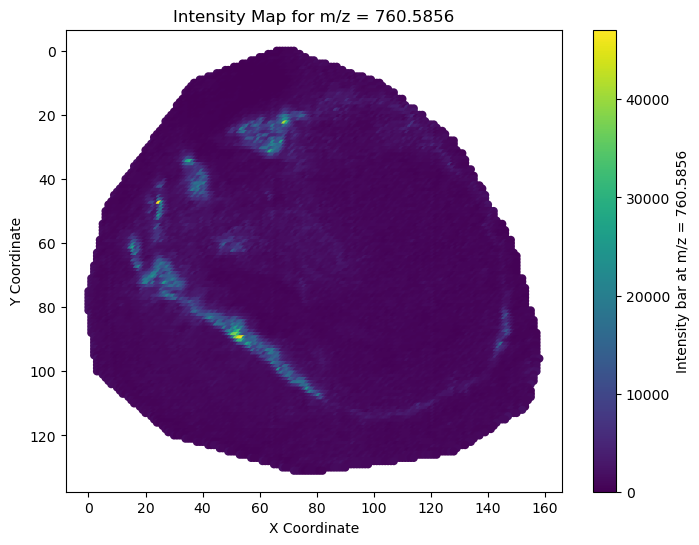

In [70]:
plot_mz_image(adata,760.5856)

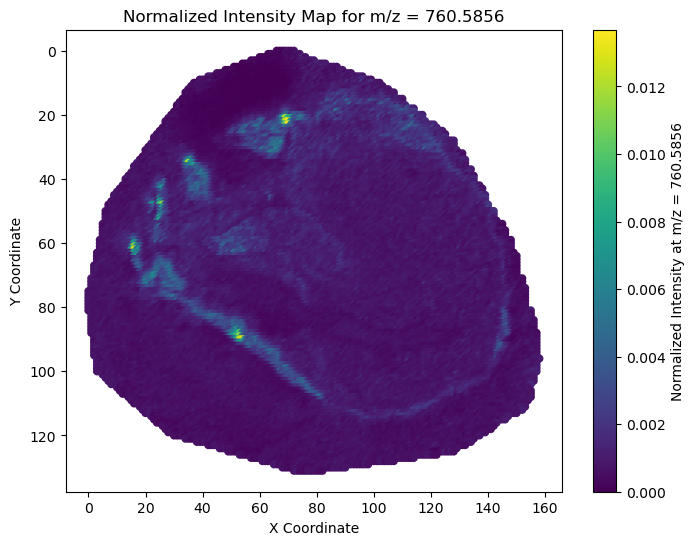

In [71]:
plot_normalized_mz_image(adata, mz_value=760.5856)

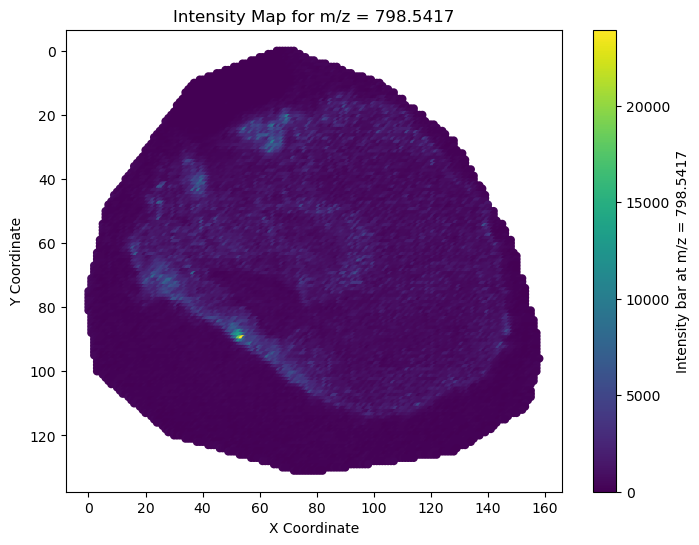

In [72]:
plot_mz_image(adata, mz_value=798.5417)

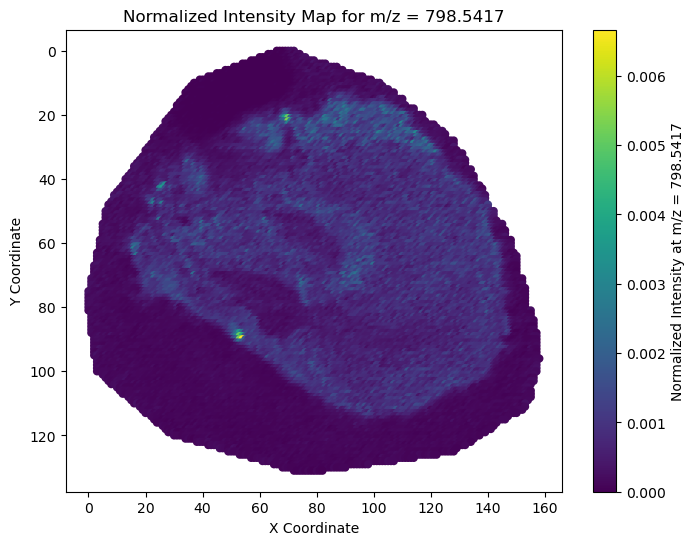

In [73]:
plot_normalized_mz_image(adata, mz_value=798.5417)